# **Experiment Notebook**



In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [2]:
student_name = 'Hanne Bolstad'

In [3]:
student_id = '25221538'

In [4]:
experiment_id = '0'

In [5]:
business_objective = 'In this project, we aim to develop a machine learning model that can predict which customers are likely to churn within the next month. This will allow us to implement a targeted retention strategy: offering a 50% discount for three months to those customers identified as high risk for churn.'

<img src="image-20241010-210619.png" width="" align="" />

<hr>

## B. Experiment Description


In [6]:
experiment_hypothesis = 'There is no hypothesis to test. This is used for data exploration and analysis and required data preparation for the upcoming experiments.'

In [7]:
experiment_expectations = 'The goal is to assess the baseline performance for this project and fix critical data quality issues impacting models.'

<hr>

## C. Data Understanding


In [8]:
data_understanding_executive_summary = 'The project utilises a comprehensive dataset comprising 34,586 customer records from a streaming service, combined from ten separate datasets provided by UTS. The data encompasses 31 features, including personal information, account details, viewing habits, and subscription characteristics. The target variable, \'Churn\', indicates a 17.75% churn rate. Key challenges include missing values in location-related fields (10.9% for Postcode and State) and Ethnicity (31.9%), which were ultimately excluded from the analysis. The dataset offers a rich mix of categorical and numerical features, providing a solid foundation for churn prediction. However, privacy concerns led to the removal of personal identifiers and sensitive demographic information. The absence of temporal data limits time-based analysis. Despite these limitations, the dataset\'s diverse features, including financial metrics (e.g., MonthlyCharges), engagement indicators (e.g., ViewingHoursPerWeek), and account characteristics (e.g., AccountAge), offer valuable insights into customer behavior and churn patterns. This comprehensive dataset, while presenting some challenges, provides a robust basis for developing a nuanced churn prediction model tailored to the streaming service industry.'

### C.0 Import Packages

In [9]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# Numpy for data handling
import numpy as np

# Seaborn for plotting
import seaborn as sns

# Matplotlib for plotting
import matplotlib.pyplot as plt

<hr>

### C.1   Load Datasets

In [10]:
# Load data
# Do not change this code

df0 = pd.read_csv("subscription_data_0.csv")
df1 = pd.read_csv("subscription_data_1.csv")
df2 = pd.read_csv("subscription_data_2.csv")
df3 = pd.read_csv("subscription_data_3.csv")
df4 = pd.read_csv("subscription_data_4.csv")
df5 = pd.read_csv("subscription_data_5.csv")
df6 = pd.read_csv("subscription_data_6.csv")
df7 = pd.read_csv("subscription_data_7.csv")
df8 = pd.read_csv("subscription_data_8.csv")
df9 = pd.read_csv("subscription_data_9.csv")


<hr>

### C.2 Explore Datasets

In [11]:
df0


,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12185,Jennifer,Bennett,2970,Martinez Isle,Drives,Bethanyfort,25844.0,MT,NaN,11,...,Action,2.557163,4,Female,3,Yes,Yes,EJQSZBW6E5,0,0-4-25844.0
12186,Amber,Wang,94352,Murphy Harbors,Flat,Rachelhaven,13733.0,FM,NaN,37,...,Sci-Fi,1.108598,2,Female,21,No,No,2QCXDDLCA0,0,0-4-13733.0
12187,Kimberly,Johnson,3917,Bryan Drive,Oval,South Patricia,88670.0,IL,NaN,12,...,Sci-Fi,3.836587,4,Male,0,No,No,LDYUJH7NYQ,1,1-4-88670.0
12188,Nicholas,Thomas,2888,Jennifer Mission,Stream,Lake Thomas,25720.0,OR,NaN,119,...,Sci-Fi,1.730010,2,Male,5,Yes,Yes,2YLQD4OOY2,0,1-4-25720.0


In [12]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12190 entries, 0 to 12189
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 12190 non-null  object 
 1   LastName                  12187 non-null  object 
 2   BuildingNumber            12190 non-null  int64  
 3   StreetName                12190 non-null  object 
 4   StreetType                12190 non-null  object 
 5   City                      12190 non-null  object 
 6   Postcode                  10896 non-null  float64
 7   State                     10896 non-null  object 
 8   Ethnicity                 1226 non-null   object 
 9   AccountAge                12190 non-null  int64  
 10  MonthlyCharges            12190 non-null  float64
 11  TotalCharges              12190 non-null  float64
 12  SubscriptionType          12190 non-null  object 
 13  PaymentMethod             12190 non-null  object 
 14  Paperl

> Insights: Missing values in LastName, Postcode, State and Ethnicity.

In [13]:
df1

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Catherine,George,41355,Zachary Village,Well,Stephanieburgh,19353.0,AZ,white,89,...,Fantasy,2.595064,7,Female,10,No,Yes,342DFV3G9S,1,0-3-19353.0
1,Antonio,Rollins,79884,Thomas Road,Extensions,North Gavin,78854.0,GA,white,24,...,Fantasy,4.914141,1,Male,10,No,Yes,PF9S769KTG,0,1-3-78854.0
2,Brandy,Vargas,884,Hunter Villages,Summit,Monteston,78343.0,HI,hispanic,44,...,Comedy,2.458039,8,Female,8,Yes,Yes,XNVGSE0O85,1,0-2-78343.0
3,Feargal,Giles,799,Julie Point,Turnpike,APO AE 57284,NaN,NaN,white,34,...,Sci-Fi,2.664434,1,Male,5,No,No,0B0Z6PX7EO,1,1-3-nan
4,Jillian,Martin,282,Frederick Fort,Meadow,Lake Kimberly,19968.0,NJ,white,33,...,Comedy,4.345574,5,Male,0,Yes,No,CPK8B7E3RR,0,1-3-19968.0


In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 5 non-null      object 
 1   LastName                  5 non-null      object 
 2   BuildingNumber            5 non-null      int64  
 3   StreetName                5 non-null      object 
 4   StreetType                5 non-null      object 
 5   City                      5 non-null      object 
 6   Postcode                  4 non-null      float64
 7   State                     4 non-null      object 
 8   Ethnicity                 5 non-null      object 
 9   AccountAge                5 non-null      int64  
 10  MonthlyCharges            5 non-null      float64
 11  TotalCharges              5 non-null      float64
 12  SubscriptionType          5 non-null      object 
 13  PaymentMethod             5 non-null      object 
 14  PaperlessBilli

In [15]:
df2

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Samuel,Oliver,5021,Shelton Causeway,Viaduct,Mackborough,72166.0,MO,white,15,...,Comedy,3.170629,6,Female,1,No,No,X2HGS4ADSL,0,0-3-72166.0
1,Victoria,Taylor,6903,Eric Ford,Expressway,Barrontown,71754.0,MO,white,92,...,Sci-Fi,4.859899,3,Female,10,No,No,BS9SPB0STR,0,0-3-71754.0
2,Mr,Tom,46121,Gonzales Plains,Plain,Nancyfurt,65573.0,CO,asian,33,...,Sci-Fi,1.189857,1,Female,23,Yes,No,YBORF9BXUU,0,0-0-65573.0
3,Joanna,Price,442,Joan Vista,Crescent,South Joyce,56105.0,IL,white,90,...,Comedy,1.577972,3,Female,11,No,No,RVYUS3NCYP,0,0-3-56105.0
4,Alana,Doolan,9501,Jessica Shores,Islands,Amandachester,87247.0,FM,white,113,...,Sci-Fi,3.405001,4,Male,24,Yes,Yes,LA8VABTNIT,0,1-3-87247.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2764,Marcus,Holder,43862,Cynthia Path,Mission,Lake Sheena,95735.0,FM,NaN,61,...,Comedy,1.422614,0,Male,18,No,No,Z0CF8FOL66,0,1-4-95735.0
2765,Matilda,Valentino,197,Thomas Inlet,Bridge,Kleinton,18736.0,FL,NaN,29,...,Action,4.132443,6,Male,24,No,No,5LBNNOLOQA,0,1-4-18736.0
2766,Ayesha,Chauhan,4032,Neal Walk,Land,DPO AE 09693,NaN,NaN,NaN,70,...,Fantasy,2.281081,4,Female,7,No,No,BODNCE425D,0,0-4-nan
2767,Sofía,Trejo,9126,Leonard Alley,Trafficway,North Monica,74001.0,FL,NaN,78,...,Fantasy,4.593817,0,Male,5,No,Yes,YTMORT59YL,1,1-4-74001.0


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2769 entries, 0 to 2768
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2769 non-null   object 
 1   LastName                  2769 non-null   object 
 2   BuildingNumber            2769 non-null   int64  
 3   StreetName                2769 non-null   object 
 4   StreetType                2769 non-null   object 
 5   City                      2769 non-null   object 
 6   Postcode                  2486 non-null   float64
 7   State                     2486 non-null   object 
 8   Ethnicity                 2757 non-null   object 
 9   AccountAge                2769 non-null   int64  
 10  MonthlyCharges            2769 non-null   float64
 11  TotalCharges              2769 non-null   float64
 12  SubscriptionType          2769 non-null   object 
 13  PaymentMethod             2769 non-null   object 
 14  Paperles

In [17]:
df3

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Lori,Jarvis,846,Alan Meadows,Lane,FPO AE 78469,NaN,NaN,white,11,...,Drama,3.075018,0,Female,17,No,No,KEQ4VEG2FJ,0,0-3-nan
1,Dr,Colin,45125,Little Terrace,River,North Jenniferton,4128.0,ID,white,22,...,Action,2.806335,5,Female,24,Yes,No,LL3XRMABSB,0,0-3-4128.0
2,David,Perez,31258,Robert Shoals,Islands,Thomasberg,67735.0,WY,hispanic,4,...,Drama,2.467155,1,Female,11,Yes,Yes,5ZG93RBWOD,0,0-2-67735.0
3,Allison,Baldwin,743,Nichols Summit,Throughway,Port Emma,40097.0,MS,white,74,...,Comedy,2.402098,9,Female,18,No,Yes,3J4ZFIXKJR,1,0-3-40097.0
4,Tammy,Martinez,495,Lindsey Freeway,Branch,East Douglasfort,24108.0,WA,hispanic,114,...,Drama,3.669507,0,Female,10,Yes,Yes,DRSOGC6UB2,1,0-2-24108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2788,Taran,Chowdhury,714,Greene Isle,Views,Russellmouth,64333.0,FL,NaN,18,...,Fantasy,2.698020,4,Male,1,No,No,6FIBT0PIUZ,0,1-4-64333.0
2789,Dr.,Kealan,15637,Brown Locks,Junction,FPO AE 45889,NaN,NaN,NaN,63,...,Drama,1.319616,0,Male,23,No,No,AFOU6ECBH7,0,1-4-nan
2790,Reina,Armando,8059,Collins Common,Road,Gibsonland,38058.0,KY,NaN,47,...,Drama,1.402909,4,Female,17,No,Yes,8QAH9OABHL,1,0-4-38058.0
2791,Corey,Duff,39070,Lindsey Hollow,Well,Padillastad,53977.0,WV,NaN,74,...,Fantasy,4.589844,0,Female,22,No,Yes,ZB1IXR3K2Y,0,0-4-53977.0


In [18]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2793 non-null   object 
 1   LastName                  2793 non-null   object 
 2   BuildingNumber            2793 non-null   int64  
 3   StreetName                2793 non-null   object 
 4   StreetType                2793 non-null   object 
 5   City                      2793 non-null   object 
 6   Postcode                  2479 non-null   float64
 7   State                     2479 non-null   object 
 8   Ethnicity                 2777 non-null   object 
 9   AccountAge                2793 non-null   int64  
 10  MonthlyCharges            2793 non-null   float64
 11  TotalCharges              2793 non-null   float64
 12  SubscriptionType          2793 non-null   object 
 13  PaymentMethod             2793 non-null   object 
 14  Paperles

In [19]:
df4

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Anel,Estrada,4338,Julia Passage,Fords,West Maria,11702.0,DE,hispanic,47,...,Action,2.426359,3,Male,10,No,Yes,TQ839ANJNY,0,1-2-11702.0
1,Tiffany,Davis,61183,Huynh Valleys,Meadows,East Kyle,24902.0,TN,white,17,...,Sci-Fi,2.488114,5,Female,21,No,No,BEHRE4ADRB,0,0-3-24902.0
2,Mark,Wolfe,557,Anderson Streets,Route,Port Veronica,30365.0,MH,white,102,...,Sci-Fi,3.336710,5,Male,24,No,Yes,9J2WF0F2JA,0,1-3-30365.0
3,Olivia,Smith-Webb,88361,Beverly Park,Manors,East Matthewside,37495.0,CA,white,8,...,Drama,3.062146,9,Female,1,No,No,3FJE6IKMR6,0,0-3-37495.0
4,Kelly,Parker,91997,Davis Oval,Trail,Port George,28994.0,VA,white,87,...,Drama,1.027004,1,Male,22,Yes,Yes,NODJVM52VF,0,1-3-28994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2789,Owen,Webb-Hall,9555,Tanner Crescent,Manor,Kleinmouth,80406.0,LA,NaN,116,...,Sci-Fi,2.706995,4,Male,13,Yes,Yes,CID49ZBKDV,0,1-4-80406.0
2790,Dulce,Mariana,2308,Keith Path,Falls,New Jeffreyberg,57722.0,WV,NaN,8,...,Fantasy,4.593740,4,Male,18,Yes,No,G5JJSA8FZC,1,1-4-57722.0
2791,Colin,Collier-Russell,367,Sanchez Dale,Wall,Albertchester,34734.0,VA,NaN,34,...,Fantasy,1.801052,3,Male,20,Yes,No,TMEUZH71N3,0,1-4-34734.0
2792,Dr,Max,1951,Brown Gateway,Forks,North Scottfort,50085.0,IA,NaN,18,...,Action,2.877378,8,Female,8,No,Yes,OV4G17PDA6,1,0-4-50085.0


In [20]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2794 entries, 0 to 2793
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2794 non-null   object 
 1   LastName                  2794 non-null   object 
 2   BuildingNumber            2794 non-null   int64  
 3   StreetName                2794 non-null   object 
 4   StreetType                2794 non-null   object 
 5   City                      2794 non-null   object 
 6   Postcode                  2467 non-null   float64
 7   State                     2467 non-null   object 
 8   Ethnicity                 2784 non-null   object 
 9   AccountAge                2794 non-null   int64  
 10  MonthlyCharges            2794 non-null   float64
 11  TotalCharges              2794 non-null   float64
 12  SubscriptionType          2794 non-null   object 
 13  PaymentMethod             2794 non-null   object 
 14  Paperles

In [21]:
df5

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Dr,Joanne,78407,Robert Port,Prairie,Trujilloton,53745.0,MH,white,24,...,Fantasy,2.726895,6,Male,16,No,No,AOUOY4IW12,0,1-3-53745.0
1,Kevin,Ross,1422,Hernandez Track,Springs,Hernandezland,86174.0,LA,white,21,...,Drama,3.705761,7,Male,10,No,No,QNJ2RK63VQ,0,1-3-86174.0
2,Anthony,Ortiz,112,Charles Mount,Pine,North Robert,25538.0,PW,hispanic,37,...,Fantasy,4.821065,5,Female,0,Yes,Yes,X5V2QRLEM7,0,0-2-25538.0
3,Michèle,Veilleux,2510,Melton Courts,Divide,Hallburgh,53299.0,MA,white,28,...,Sci-Fi,3.552793,4,Male,13,Yes,Yes,RNADD4EFY4,1,1-3-53299.0
4,Alexander,Maddox,956,Hall Ports,Tunnel,APO AP 99767,NaN,NaN,white,71,...,Comedy,4.010169,7,Male,0,Yes,No,1ZZPS6K42I,0,1-3-nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2811,Dean,Maccarthy,811,Smith Walks,Drives,Kimberlyborough,74728.0,SD,NaN,114,...,Comedy,1.932391,5,Female,17,No,No,RPQ5OSDOAW,0,0-4-74728.0
2812,Laurie,Connaughton-Bolger,63901,Jones Pine,Shore,Port Derekborough,23560.0,NE,NaN,10,...,Action,2.837177,5,Female,5,No,Yes,SX4SYY9UIY,0,0-4-23560.0
2813,Mrs,Rachael,796,Elizabeth Junctions,Alley,FPO AP 84828,NaN,NaN,NaN,51,...,Action,1.920531,6,Female,9,No,Yes,RG368NSBQQ,0,0-4-nan
2814,Christine,Arthurs,76016,Desiree Loop,Center,Hamiltonburgh,72003.0,KS,NaN,104,...,Drama,4.590896,7,Male,4,Yes,No,9SCPGPR8O6,0,1-4-72003.0


In [22]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2816 entries, 0 to 2815
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2816 non-null   object 
 1   LastName                  2816 non-null   object 
 2   BuildingNumber            2816 non-null   int64  
 3   StreetName                2816 non-null   object 
 4   StreetType                2816 non-null   object 
 5   City                      2816 non-null   object 
 6   Postcode                  2500 non-null   float64
 7   State                     2500 non-null   object 
 8   Ethnicity                 2810 non-null   object 
 9   AccountAge                2816 non-null   int64  
 10  MonthlyCharges            2816 non-null   float64
 11  TotalCharges              2816 non-null   float64
 12  SubscriptionType          2816 non-null   object 
 13  PaymentMethod             2816 non-null   object 
 14  Paperles

In [23]:
df6

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Erika,Williams,5143,Sanchez Mountain,Inlet,South Renee,22837.0,SD,black,118,...,Sci-Fi,2.455370,6,Male,15,No,Yes,WA0OMI1BSD,0,1-1-22837.0
1,Kim,Long,24429,Joshua Loaf,Expressway,Jessetown,41712.0,NH,white,95,...,Drama,4.682225,9,Female,17,Yes,Yes,PQEK3ZRD14,0,0-3-41712.0
2,Lee,Winter,53004,Curtis Tunnel,Isle,Matthewmouth,55827.0,AS,white,80,...,Drama,1.868602,2,Male,4,No,No,MZ7PMZCSQL,0,1-3-55827.0
3,Imelda,Tarantino-Aloisio,6730,Matthew River,Shore,North Staciechester,70116.0,MA,white,111,...,Sci-Fi,3.458868,6,Female,12,Yes,Yes,WCSKRZ1N4H,0,0-3-70116.0
4,Samantha,Wells,138,Barbara Islands,Alley,Alejandraland,6247.0,VA,white,80,...,Fantasy,2.393086,6,Male,19,Yes,No,ECVYE0COK9,0,1-3-6247.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,Mx.,Christina,9795,Jackson Shore,Tunnel,Hunterstad,55421.0,KS,NaN,100,...,Drama,4.020993,7,Female,19,No,No,9L82AM0YAD,0,0-4-55421.0
2796,Patrick,Gould-Skinner,1650,Flores Mills,Brooks,Kevinhaven,31764.0,KY,NaN,27,...,Comedy,3.567039,7,Female,0,No,No,4EP3BF78BG,1,0-4-31764.0
2797,Aarush,Yadav,925,Moore Prairie,Trail,Shelleyland,31213.0,ME,NaN,35,...,Sci-Fi,4.060511,6,Female,15,No,No,X4KSJ27APO,0,0-4-31213.0
2798,Sig.ra,Renata,3901,Smith Lights,Squares,Lake Vanessachester,23440.0,AR,NaN,67,...,Sci-Fi,4.332248,5,Female,2,No,Yes,2JDZNAWJ7J,1,0-4-23440.0


In [24]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2800 non-null   object 
 1   LastName                  2800 non-null   object 
 2   BuildingNumber            2800 non-null   int64  
 3   StreetName                2800 non-null   object 
 4   StreetType                2800 non-null   object 
 5   City                      2800 non-null   object 
 6   Postcode                  2496 non-null   float64
 7   State                     2496 non-null   object 
 8   Ethnicity                 2782 non-null   object 
 9   AccountAge                2800 non-null   int64  
 10  MonthlyCharges            2800 non-null   float64
 11  TotalCharges              2800 non-null   float64
 12  SubscriptionType          2800 non-null   object 
 13  PaymentMethod             2800 non-null   object 
 14  Paperles

In [25]:
df7

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Jasmine,Howell,190,Oneal Port,Landing,Lake Matthewview,44495.0,UT,white,4,...,Comedy,1.703936,1,Female,10,Yes,No,A0H9DEUMSC,0,0-3-44495.0
1,Anna,Cook,57,Ryan Island,Drives,Melissaton,7533.0,GU,white,12,...,Comedy,2.731431,5,Female,10,No,Yes,2TYSL7W612,1,0-3-7533.0
2,Katrina,Chang,4639,Stephenson Mills,Shoals,APO AA 34814,NaN,NaN,asian,45,...,Action,2.300513,3,Female,22,Yes,No,LSHZP65UMV,0,0-0-nan
3,Mr.,Zachary,6838,John Station,Causeway,Port Tyler,21488.0,MN,white,102,...,Action,1.546935,9,Male,11,No,No,MJCN1QCTFO,0,1-3-21488.0
4,Heather,Young,12938,Melissa Tunnel,Circles,North Shaunview,6840.0,OK,white,15,...,Fantasy,1.896405,9,Male,3,No,Yes,SX8GYAVL1F,0,1-3-6840.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2780,Ayesha,Walia,4619,Karen Knoll,Mission,Austinshire,20681.0,OK,NaN,49,...,Drama,3.472866,4,Female,17,No,Yes,IXAD1WK1E8,1,0-4-20681.0
2781,Mrs,Donna,2770,Robert Islands,Radial,Maryview,92225.0,AS,NaN,109,...,Drama,4.687383,8,Male,13,No,No,8OXALNZE4Y,1,1-4-92225.0
2782,Eloisa,Barbara,9179,Amanda Lodge,Square,Gabrielleton,88638.0,OH,NaN,30,...,Action,1.095262,3,Male,20,Yes,Yes,9IL84M2ES1,0,1-4-88638.0
2783,Roy,Connor,156,Blackburn Ranch,Rapid,Victorview,63706.0,PR,NaN,112,...,Fantasy,4.174782,6,Male,0,No,Yes,GTCH8IUDZW,0,1-4-63706.0


In [26]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785 entries, 0 to 2784
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2785 non-null   object 
 1   LastName                  2785 non-null   object 
 2   BuildingNumber            2785 non-null   int64  
 3   StreetName                2785 non-null   object 
 4   StreetType                2785 non-null   object 
 5   City                      2785 non-null   object 
 6   Postcode                  2489 non-null   float64
 7   State                     2489 non-null   object 
 8   Ethnicity                 2779 non-null   object 
 9   AccountAge                2785 non-null   int64  
 10  MonthlyCharges            2785 non-null   float64
 11  TotalCharges              2785 non-null   float64
 12  SubscriptionType          2785 non-null   object 
 13  PaymentMethod             2785 non-null   object 
 14  Paperles

In [27]:
df8

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Jesse,Mcintyre,223,Conrad Summit,Flat,East Darlene,29112.0,WY,white,107,...,Comedy,2.901723,7,Female,5,No,No,8LJ2E9ADDH,0,0-3-29112.0
1,Dr.,Todd,5249,Taylor Harbors,Islands,Lisaville,77540.0,ID,white,80,...,Action,4.620689,6,Male,15,No,Yes,U794G44B8D,1,1-3-77540.0
2,Pamela,Luna,2240,John Overpass,Oval,Jessicaside,87363.0,MS,hispanic,11,...,Comedy,2.632730,9,Female,16,No,Yes,2VAIR4ROVX,0,0-2-87363.0
3,Christopher,Day,966,Carla Isle,Keys,Wilsonborough,12497.0,NH,white,109,...,Action,3.273230,8,Female,1,Yes,Yes,F6L2M7MPQF,0,0-3-12497.0
4,Eamonn,Rea,340,Kim Summit,Stravenue,East Alexandriabury,57052.0,VT,white,52,...,Fantasy,1.365186,7,Male,8,Yes,Yes,FATDM2TF32,0,1-3-57052.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,Kimaya,Sankar,63693,Bauer Drive,Landing,Hollowayburgh,39580.0,FL,NaN,59,...,Sci-Fi,1.845540,9,Female,0,No,No,XWXE23IUPE,0,0-4-39580.0
2846,Natasha,Meenan,21524,Connor Square,Club,Smithberg,25360.0,AR,NaN,10,...,Comedy,3.379149,4,Female,20,Yes,No,7PL1G3L2BA,0,0-4-25360.0
2847,Olivier,Proulx,6916,Travis Ford,Prairie,Ashleyfort,57139.0,WA,NaN,4,...,Action,4.226855,0,Male,23,Yes,Yes,W6UEW3R8PF,1,1-4-57139.0
2848,Jerónimo,Villalpando,1261,Jacob Oval,Courts,West Steven,51487.0,MA,NaN,2,...,Action,4.740167,8,Female,4,No,No,4THIFI0PLK,0,0-4-51487.0


In [28]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2850 non-null   object 
 1   LastName                  2850 non-null   object 
 2   BuildingNumber            2850 non-null   int64  
 3   StreetName                2850 non-null   object 
 4   StreetType                2850 non-null   object 
 5   City                      2850 non-null   object 
 6   Postcode                  2531 non-null   float64
 7   State                     2531 non-null   object 
 8   Ethnicity                 2834 non-null   object 
 9   AccountAge                2850 non-null   int64  
 10  MonthlyCharges            2850 non-null   float64
 11  TotalCharges              2850 non-null   float64
 12  SubscriptionType          2850 non-null   object 
 13  PaymentMethod             2850 non-null   object 
 14  Paperles

In [29]:
df9

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Carolyn,Barnes,624,Joann Ridge,Hills,South Michelleton,75244.0,MD,white,49,...,Drama,2.156288,1,Male,6,Yes,No,ZZK5TMZGUK,0,1-3-75244.0
1,Lisa,Garcia,790,Joshua Unions,Walks,Lake Lauren,63949.0,CO,hispanic,17,...,Fantasy,2.874365,9,Male,4,No,No,YMHIEO2K54,0,1-2-63949.0
2,Hugh,Harrison,254,Alex Harbor,Fort,Gordonland,52236.0,FM,white,117,...,Comedy,2.300348,5,Female,5,No,Yes,5PGIGKGLAJ,0,0-3-52236.0
3,Rebecca,Edwards,14851,Rodriguez Dale,Village,East Nicholas,8980.0,WI,white,95,...,Action,3.491410,8,Male,24,Yes,No,D5GO9V5SZT,0,1-3-8980.0
4,Tricia,Salazar,321,Brown Valleys,Squares,South Sarahmouth,66421.0,MN,hispanic,14,...,Comedy,3.592129,9,Male,5,Yes,No,DVH3VTVHY1,1,1-2-66421.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2779,Lic.,Ilse,14356,Contreras Landing,Highway,APO AA 79140,NaN,NaN,white,113,...,Fantasy,2.571882,5,Male,3,No,No,BSQ3ZN2AV1,0,1-3-nan
2780,Dr,Joanna,605,Taylor River,Mews,South Kaitlynport,95400.0,AR,white,42,...,Drama,2.361023,6,Male,17,No,No,B8BLN9K629,1,1-3-95400.0
2781,Giorgio,Bajardi-Battelli,179,James Extensions,Radial,APO AE 13486,NaN,NaN,white,43,...,Action,3.695672,5,Male,6,No,No,B01577YHQO,0,1-3-nan
2782,Miss,June,762,Kyle Landing,Shore,Lake Johnbury,36487.0,MA,NaN,110,...,Fantasy,4.892557,1,Male,5,No,No,H8OZZRCV21,0,1-4-36487.0


In [30]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2784 entries, 0 to 2783
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 2784 non-null   object 
 1   LastName                  2784 non-null   object 
 2   BuildingNumber            2784 non-null   int64  
 3   StreetName                2784 non-null   object 
 4   StreetType                2784 non-null   object 
 5   City                      2784 non-null   object 
 6   Postcode                  2454 non-null   float64
 7   State                     2454 non-null   object 
 8   Ethnicity                 2782 non-null   object 
 9   AccountAge                2784 non-null   int64  
 10  MonthlyCharges            2784 non-null   float64
 11  TotalCharges              2784 non-null   float64
 12  SubscriptionType          2784 non-null   object 
 13  PaymentMethod             2784 non-null   object 
 14  Paperles

In [31]:
df9.describe()

,BuildingNumber,Postcode,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,2784.000000,2454.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000
mean,18187.087644,50628.870416,60.872486,12.455567,759.573429,20.602089,92.652743,24.640805,3.006138,4.487787,12.046695,0.172414
std,28037.689545,28830.694586,34.373849,4.265790,523.211084,11.328058,50.683987,14.638129,1.148614,2.880391,7.055907,0.377808
min,1.000000,505.000000,1.000000,4.991465,5.236498,1.025724,5.045407,0.000000,1.002327,0.000000,0.000000,0.000000
25%,672.000000,25498.750000,32.000000,8.790590,338.801120,10.980559,48.783714,12.000000,2.022831,2.000000,6.000000,0.000000
50%,4505.500000,51124.000000,61.000000,12.382898,666.017930,20.498819,92.246972,25.000000,3.025021,4.000000,12.000000,0.000000
75%,22063.000000,75550.000000,91.000000,16.105846,1100.035816,30.422888,136.636399,38.000000,4.010495,7.000000,18.000000,0.000000
max,99605.000000,99919.000000,119.000000,19.985115,2358.662283,39.946796,179.903402,49.000000,4.997870,9.000000,24.000000,1.000000


> Insights: All datasets have the same columns. To make further exploration easier the datasets will be combined. 

In [32]:
# Combine all datasets

df_combined = pd.concat([df0, df1, df2, df3, df4, df5, df6, df7, df8, df9], ignore_index=True)

In [33]:
## get total number of rows

df_combined.shape

(34586, 31)

> Insights: 34586 rows in total and 31 columns

In [34]:
# find number of rows with churn 0 and 1

churn_counts = df_combined['Churn'].value_counts()

print(f"Rows with Churn = 0: {churn_counts[0]}")
print(f"Rows with Churn = 1: {churn_counts[1]}")

Rows with Churn = 0: 28446
Rows with Churn = 1: 6140


> Insights: 6140 (or 17,75%) rows with churn

In [35]:
## look at columns and null values

df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 34586 non-null  object 
 1   LastName                  34583 non-null  object 
 2   BuildingNumber            34586 non-null  int64  
 3   StreetName                34586 non-null  object 
 4   StreetType                34586 non-null  object 
 5   City                      34586 non-null  object 
 6   Postcode                  30802 non-null  float64
 7   State                     30802 non-null  object 
 8   Ethnicity                 23536 non-null  object 
 9   AccountAge                34586 non-null  int64  
 10  MonthlyCharges            34586 non-null  float64
 11  TotalCharges              34586 non-null  float64
 12  SubscriptionType          34586 non-null  object 
 13  PaymentMethod             34586 non-null  object 
 14  Paperl

In [36]:
# Check how many null values total (excluding the 3 in last name)

total_rows = len(df_combined)

null_analysis = pd.DataFrame({
    'Column': ['Postcode', 'State', 'Ethnicity'],
    'Null Count': [
        df_combined['Postcode'].isnull().sum(),
        df_combined['State'].isnull().sum(),
        df_combined['Ethnicity'].isnull().sum()
    ]
})

null_analysis['Null Percentage'] = (null_analysis['Null Count'] / total_rows) * 100

# Show the results
print(null_analysis.to_string(index=False))

print(f"\nTotal number of rows: {total_rows}")

   Column  Null Count  Null Percentage
 Postcode        3784        10.940843
    State        3784        10.940843
Ethnicity       11050        31.949344

Total number of rows: 34586


> Insights: 10,94% of postcode and state are missing, and 31,94% of ethnicity.

In [37]:
# check for duplicates

dups = df_combined.duplicated()

print(dups)
print(df_combined[dups])

0        False
1        False
2        False
3        False
4        False
         ...  
34581    False
34582    False
34583    False
34584    False
34585    False
Length: 34586, dtype: bool
Empty DataFrame
Columns: [FirstName, LastName, BuildingNumber, StreetName, StreetType, City, Postcode, State, Ethnicity, AccountAge, MonthlyCharges, TotalCharges, SubscriptionType, PaymentMethod, PaperlessBilling, ContentType, MultiDeviceAccess, DeviceRegistered, ViewingHoursPerWeek, AverageViewingDuration, ContentDownloadsPerMonth, GenrePreference, UserRating, SupportTicketsPerMonth, Gender, WatchlistSize, ParentalControl, SubtitlesEnabled, CustomerID, Churn, Cohort]
Index: []

[0 rows x 31 columns]


> Insights: No duplicates found

In [38]:
# check values for float/integer columns

df_combined.describe()

,BuildingNumber,Postcode,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,34586.000000,30802.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.00000,34586.000000,34586.000000
mean,18382.107384,50439.623498,60.034205,12.481594,749.126439,20.575998,92.427566,24.615972,3.009000,4.49893,12.020210,0.177528
std,27820.825292,28715.400686,34.356975,4.303706,523.014579,11.233775,50.592829,14.450537,1.154705,2.87045,7.191615,0.382121
min,0.000000,501.000000,1.000000,4.990062,5.101684,1.000133,5.002643,0.000000,1.000007,0.00000,0.000000,0.000000
25%,670.000000,25490.250000,30.000000,8.744131,330.732530,10.876132,48.448066,12.000000,2.007270,2.00000,6.000000,0.000000
50%,4495.000000,50572.000000,60.000000,12.472481,644.610183,20.666960,92.674569,25.000000,3.021349,4.00000,12.000000,0.000000
75%,24926.750000,75218.500000,90.000000,16.174570,1087.452915,30.302291,136.051872,37.000000,4.007800,7.00000,18.000000,0.000000
max,99999.000000,99947.000000,119.000000,19.989412,2373.700290,39.998560,179.999025,49.000000,4.999845,9.00000,24.000000,1.000000


In [39]:
df_combined['State'].unique()

array(['NY', nan, 'HI', 'WV', 'RI', 'IN', 'MO', 'KY', 'MD', 'NE', 'TN',
       'IA', 'AL', 'LA', 'GU', 'CO', 'SC', 'PW', 'OR', 'NJ', 'NM', 'VA',
       'FL', 'TX', 'ME', 'OK', 'NH', 'VI', 'UT', 'NV', 'WY', 'DE', 'ID',
       'DC', 'PR', 'AZ', 'ND', 'MS', 'OH', 'MP', 'GA', 'VT', 'KS', 'SD',
       'WA', 'AR', 'MN', 'MI', 'AS', 'IL', 'CT', 'PA', 'NC', 'WI', 'MH',
       'AK', 'CA', 'FM', 'MA', 'MT'], dtype=object)

In [40]:
columns_to_show = ['City', 'Postcode', 'State', 'Churn']
missing_postcode = df_combined[df_combined['Postcode'].isna()][columns_to_show]
print(missing_postcode)

               City  Postcode State  Churn
1      DPO AA 59306       NaN   NaN      0
14     FPO AE 59075       NaN   NaN      0
17     DPO AA 08102       NaN   NaN      0
21     DPO AP 46562       NaN   NaN      0
53     APO AE 16319       NaN   NaN      0
...             ...       ...   ...    ...
34565  FPO AP 92150       NaN   NaN      1
34573  FPO AA 75711       NaN   NaN      0
34580  FPO AE 34575       NaN   NaN      0
34581  APO AA 79140       NaN   NaN      0
34583  APO AE 13486       NaN   NaN      0

[3784 rows x 4 columns]


In [41]:
churn_counts = missing_postcode['Churn'].value_counts()

print(f"Rows with Churn = 0: {churn_counts[0]}")
print(f"Rows with Churn = 1: {churn_counts[1]}")

Rows with Churn = 0: 3100
Rows with Churn = 1: 684


In [42]:
# Check unique values

df_combined['SubscriptionType'].unique()

array(['Premium', 'Basic', 'Standard'], dtype=object)

In [43]:
df_combined['PaymentMethod'].unique()

array(['Mailed check', 'Credit card', 'Electronic check', 'Bank transfer'],
      dtype=object)

In [44]:
df_combined['PaperlessBilling'].unique()

array(['No', 'Yes'], dtype=object)

In [45]:
df_combined['ContentType'].unique()

array(['Both', 'Movies', 'TV Shows'], dtype=object)

In [46]:
df_combined['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [47]:
df_combined['MultiDeviceAccess'].unique()

array(['No', 'Yes'], dtype=object)

In [48]:
df_combined['DeviceRegistered'].unique()

array(['Mobile', 'Tablet', 'Computer', 'TV'], dtype=object)

> Insights: No abnormal values found. 

> Insights: There are 10 datasets with the same 31 columns. The first (df0) is the largest with 12.190 rows, while df2-df9 are the same size, about 2700-2800 rows. Df1 only has 5. In total there are 34.586 rows, where 28446 rows have churn=0 and 6140 Churn=1. No duplicates.

> Considerations: Should combine all 10 datasets and then splitt 60-20-20 (train, val, test). The first 6 columns are not useful and pose the risk of privacy issues so these should be removed. The use of the ethnicity column should be considered carefully. I think it could be interesting to look at its effect. However, due to the significantly high number of missing values (32%) it might not be worth it. Furthermore, using this type of feature raises concerns about potential unintended discrimination and bias, maybe even legal risks. Overall, I don't think it is worth it.

> Issues found: In all the datasets there are missing values in the postcode, state and ethnicity columns. 10.9% of the first two and alomost 32% of ethnicity. It seems the missing values in postcode and state is due to army/navy/diplomatic address abroad. Location could be interesting to look at. If so, the null values could be changed to another value to distingush people abroad.

<hr>

### C.3 Explore Target variable

In [49]:
# Set the name of the target column

target_name = 'Churn'

In [50]:
print(df_combined['Churn'].describe())


count    34586.000000
mean         0.177528
std          0.382121
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Churn, dtype: float64


> Insights: Total 34.586, 17.75% churn.

In [51]:
## Check for other values

df_combined['Churn'].unique()

array([0, 1])

> Insights: No other values than 1 and 0.

In [52]:
## Count churn per dataset and percentage


def analyze_churn(df):
    total_rows = len(df)
    churn_count = df['Churn'].sum()
    churn_percentage = (churn_count / total_rows) * 100
    return total_rows, churn_count, churn_percentage

results = []

for i in range(10):  # This will loop from 0 to 9
    df_name = f'df{i}'
    if df_name in globals():
        df = globals()[df_name]
        total, count, percentage = analyze_churn(df)
        results.append({
            'Dataset': df_name,
            'Total Rows': total,
            'Churn Count': count,
            'Churn Percentage': percentage
        })

results_df = pd.DataFrame(results)
results_df['Churn Percentage'] = results_df['Churn Percentage'].round(2)

print(results_df.to_string(index=False))

# To get overall statistics
overall_total = results_df['Total Rows'].sum()
overall_churn = results_df['Churn Count'].sum()
overall_percentage = (overall_churn / overall_total) * 100

print("\nOverall Statistics:")
print(f"Total Rows: {overall_total}")
print(f"Total Churn: {overall_churn}")
print(f"Overall Churn Percentage: {overall_percentage:.2f}%")

Dataset  Total Rows  Churn Count  Churn Percentage
    df0       12190         2175             17.84
    df1           5            3             60.00
    df2        2769          480             17.33
    df3        2793          485             17.36
    df4        2794          490             17.54
    df5        2816          514             18.25
    df6        2800          507             18.11
    df7        2785          512             18.38
    df8        2850          494             17.33
    df9        2784          480             17.24

Overall Statistics:
Total Rows: 34586
Total Churn: 6140
Overall Churn Percentage: 17.75%


> Insights: Aside from df1 all datasets contain 17-18% churns.

In [53]:
# Calculate average monthly charge for customers who have churned

df_combined[df_combined['Churn'] == 1]['MonthlyCharges'].mean()


13.404520544208182

> Considerations: The dataset exhibits a class imbalance with a churn rate of 17.75%. This imbalance needs to be addressed in our modeling approach to ensure we don't overlook the minority class (churn).

> Issues found: Since churn is binary, it doesn't provide information about when customers churned or how long they were customers. This would be useful information to have for the model, but does not appear in the dataset.

<hr>

### C.4 Explore Variables of Interest

<hr>

#### C.4.a Feature "AccountAge"

In [54]:
df_combined['AccountAge'].describe()

count    34586.000000
mean        60.034205
std         34.356975
min          1.000000
25%         30.000000
50%         60.000000
75%         90.000000
max        119.000000
Name: AccountAge, dtype: float64

> Insights: The AccountAge range is from 1 to 119 months, average 60 months.

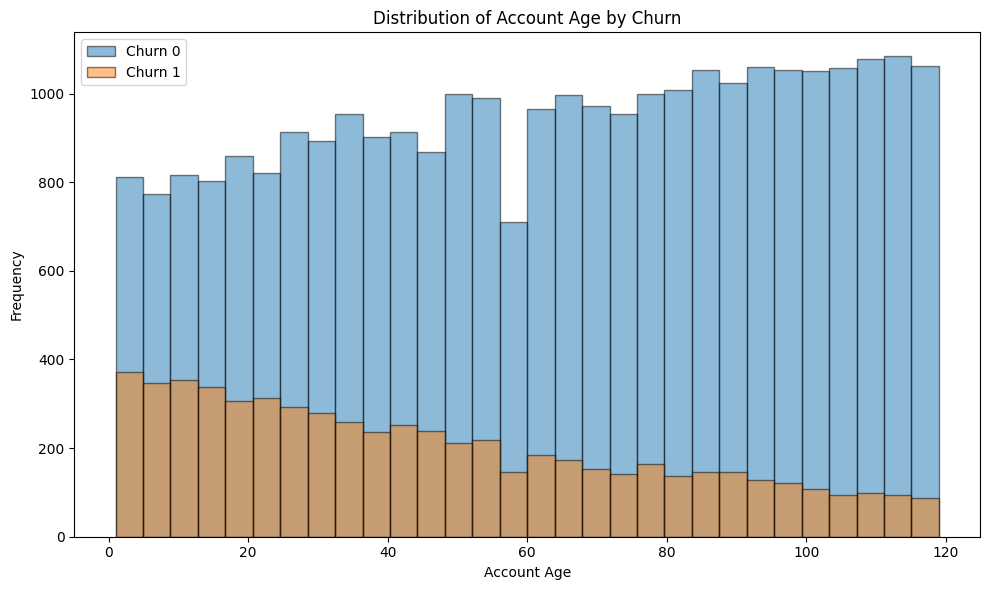

In [55]:
# Plot distribution of AccountAge by churn and no-churn


plt.figure(figsize=(10, 6))

# Separate for Churn = 0 and 1
age_churn_0 = df_combined[df_combined['Churn'] == 0]['AccountAge']
age_churn_1 = df_combined[df_combined['Churn'] == 1]['AccountAge']

plt.hist(age_churn_0, bins=30, alpha=0.5, label='Churn 0', edgecolor='black')
plt.hist(age_churn_1, bins=30, alpha=0.5, label='Churn 1', edgecolor='black')

plt.title('Distribution of Account Age by Churn')
plt.xlabel('Account Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()

plt.show()

> Insights: The number of churns decreases as the membership ages, and the number of no churn increases. This means that there is a higher chance of customer churning in the beginning.

> Considerations: AccountAge spans from 1 to 119 months, with an average of 60 months, providing a good understanding of customer lifecycles from new acquisitions to long-term members. It shows a negative correlation with churn probability. Newer accounts are at higher risk of churning, while longer-tenured accounts show increased loyalty.

> Issues found: While AccountAge shows a clear relationship with churn, it's important to investigate potential interaction effects with other variables (e.g., subscription type, usage patterns) to fully understand its impact on churn risk.

#### C.4.b Feature "MonthlyCharges"

In [56]:
## Check monthly charges and total charges

print(df_combined['MonthlyCharges'].describe())
print(df_combined['TotalCharges'].describe())

count    34586.000000
mean        12.481594
std          4.303706
min          4.990062
25%          8.744131
50%         12.472481
75%         16.174570
max         19.989412
Name: MonthlyCharges, dtype: float64
count    34586.000000
mean       749.126439
std        523.014579
min          5.101684
25%        330.732530
50%        644.610183
75%       1087.452915
max       2373.700290
Name: TotalCharges, dtype: float64


> Insights: MonthlyCharges and TotalCharges show a wide range of values, capturing diverse customer spending patterns from budget to premium subscribers. No null values.

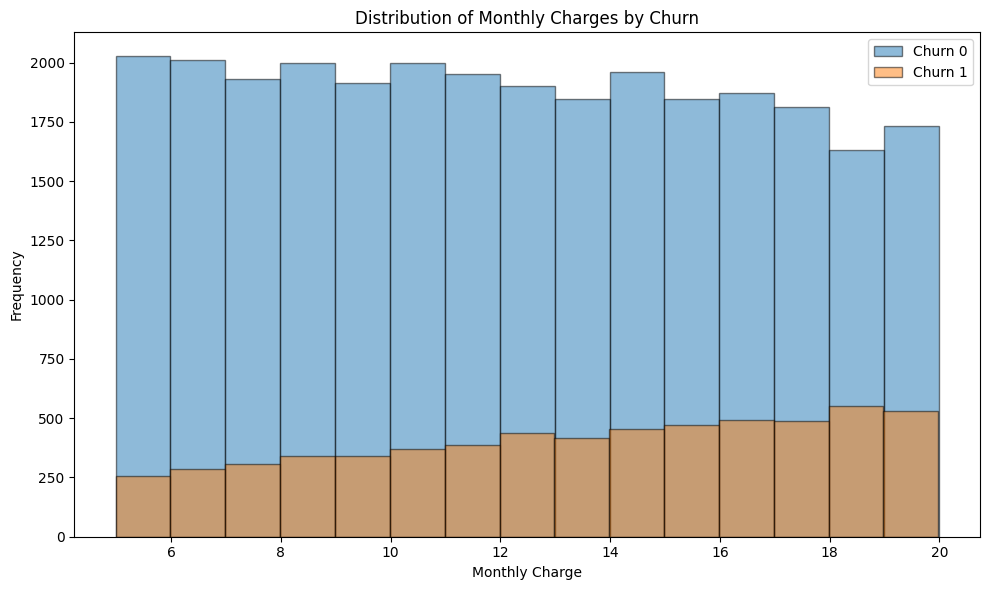

In [57]:
# Plot distribution of monthly charges by churn and no-churn


plt.figure(figsize=(10, 6))

# Separate for Churn = 0 and 1
mcharge_churn_0 = df_combined[df_combined['Churn'] == 0]['MonthlyCharges']
mcharge_churn_1 = df_combined[df_combined['Churn'] == 1]['MonthlyCharges']

plt.hist(mcharge_churn_0, bins=15, alpha=0.5, label='Churn 0', edgecolor='black')
plt.hist(mcharge_churn_1, bins=15, alpha=0.5, label='Churn 1', edgecolor='black')

plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charge')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()

plt.show()

> Insights: MonthlyCharges shows a slight positive correlation with churn probability, suggesting that customers with higher monthly bills are somewhat more likely to churn.

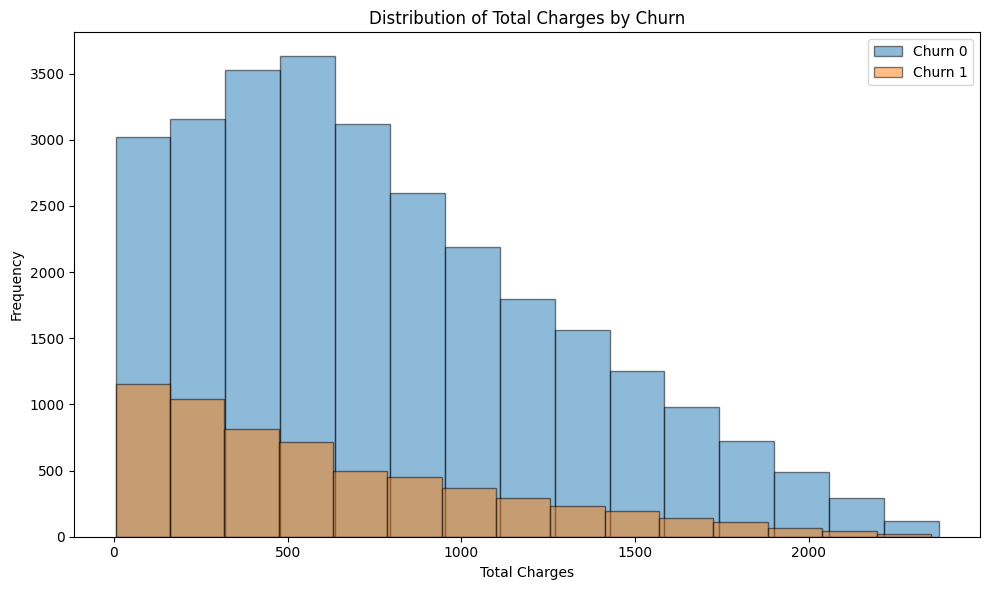

In [58]:
# Plot distribution of total charges by churn and no-churn

plt.figure(figsize=(10, 6))

# Separate for Churn = 0 and 1
tcharge_churn_0 = df_combined[df_combined['Churn'] == 0]['TotalCharges']
tcharge_churn_1 = df_combined[df_combined['Churn'] == 1]['TotalCharges']

plt.hist(tcharge_churn_0, bins=15, alpha=0.5, label='Churn 0', edgecolor='black')
plt.hist(tcharge_churn_1, bins=15, alpha=0.5, label='Churn 1', edgecolor='black')

plt.title('Distribution of Total Charges by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()

plt.show()



> Insights: TotalCharges appears to be derived from MonthlyCharges and AccountAge, providing a cumulative view of customer value over time.

> Considerations: The high correlation between TotalCharges and MonthlyCharges may lead to multicollinearity issues in some models. Feature selection or regularization techniques may be necessary to address this

> Issues found: TotalCharges contains potential outliers, with the maximum value being significantly higher than the 75th percentile. These outliers should be investigated and potentially handled depending on the modeling approach.

#### C.4.c Feature "ViewingHoursPerWeek"

In [59]:
df_combined ['ViewingHoursPerWeek'].describe()

count    34586.000000
mean        20.575998
std         11.233775
min          1.000133
25%         10.876132
50%         20.666960
75%         30.302291
max         39.998560
Name: ViewingHoursPerWeek, dtype: float64

Insights: ViewingHoursPerWeek shows a wide range from 1 to 40 hours, capturing diverse viewing habits from casual to heavy users.

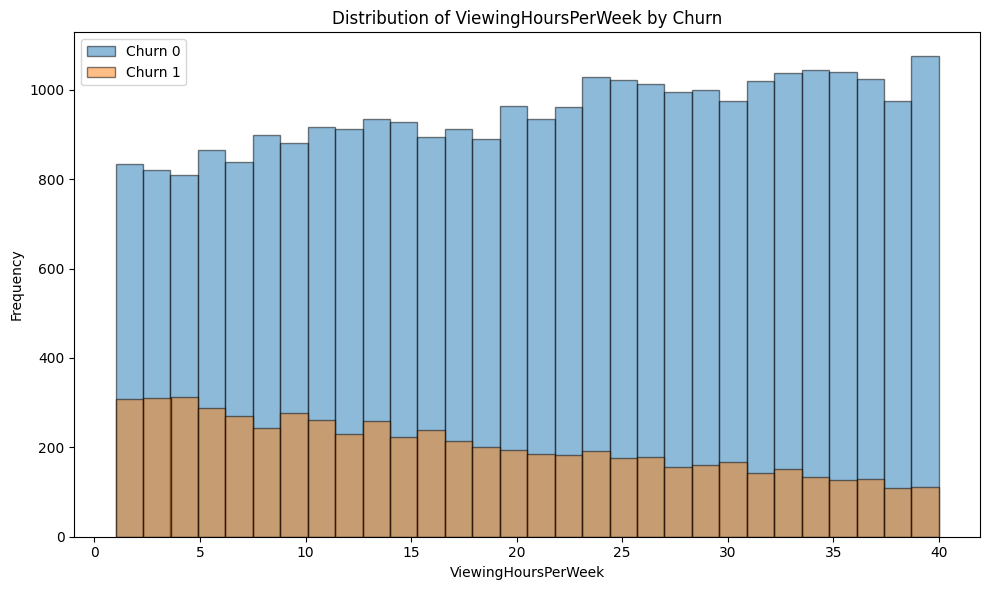

In [60]:
plt.figure(figsize=(10, 6))

# Separate for Churn = 0 and 1
VPH_churn_0 = df_combined[df_combined['Churn'] == 0]['ViewingHoursPerWeek']
VPH_churn_1 = df_combined[df_combined['Churn'] == 1]['ViewingHoursPerWeek']

#
plt.hist(VPH_churn_0, bins=30, alpha=0.5, label='Churn 0', edgecolor='black')
plt.hist(VPH_churn_1, bins=30, alpha=0.5, label='Churn 1', edgecolor='black')

plt.title('Distribution of ViewingHoursPerWeek by Churn')
plt.xlabel('ViewingHoursPerWeek')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()

plt.show()

Insights: ViewingHoursPerWeek serves as a key engagement metric, offering insights into how actively customers are using the streaming service.

<hr>

## D. Feature Selection


In [61]:
feature_selection_executive_summary = 'Feature selection and engineering were conducted with a focus on behavioral and financial factors directly relevant to churn prediction. Mutual Information and Random Forest importance scores were used to identify the most predictive features. Prior to feature selection, irrelevant features were removed and the dataset was split. '

### D.1 Approach 1

> Rationale: Remove the following features: first and last name, building number, street name, street type, city, postcode, state, customerID, ethnicity and Cohort. The removal of these features aligns with best practices in data science and ethical AI development. It prioritizes customer privacy, reduces the risk of introducing biased or discriminatory elements into the model, and focuses the analysis on behaviorally and financially relevant factors that are more likely to have a direct impact on churn prediction.
This approach ensures that the model is built on pertinent, ethically sound data, potentially improving its generalizability and reducing legal and reputational risks associated with using sensitive personal information.

In [62]:
# Remove irrelevant features

irrelevant_features = ['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType', 'City', 'Postcode', 'State', 'CustomerID', 'Ethnicity', 'Cohort']
df = df_combined.drop(columns=irrelevant_features)

df.shape

(34586, 20)

> Results: The dataset now contains 20 columns and no indentifiable, personal information.



### D.2 Approach 2

> Rationale: Before conducting the feature selection, the dataset will be split into training, validation, and testing sets. This approach is crucial for preventing data leakage and ensuring an unbiased evaluation of the model's performance. By keeping the validation and test sets completely separate from the feature selection process, we maintain their integrity as truly unseen data.

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

# Slit test set (20% of the data)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split remaining 80% into training (75% of 80% = 60% of total) and validation (25% of 80% = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Verify the sizes of our splits
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X):.2%})")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X):.2%})")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X):.2%})")

Total samples: 34586
Training samples: 20751 (60.00%)
Validation samples: 6917 (20.00%)
Test samples: 6918 (20.00%)


In [64]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(20751, 19) (20751,)
(6917, 19) (6917,)
(6918, 19) (6918,)


> Results: The whole dataset (everything from df0-df9) is split into training (60%), validation (20%) and testing (20%)

### D.3 Approach 3

Rationale: To help me select the features I will use Mutaul Information (MI) and Random Forest (RF). MI can capture non-linear relationships between features and the target variable, while RF can capture complex interactions between features. Using both of them together gives a solid and complementary perspective on feature importance and reduces the risk of overlooking an important feature.

In [65]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Split features and target

X = X_train
y = y_train


# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit the preprocessor
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after preprocessing
feature_names = (numeric_features.tolist() +
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_features).tolist())

# Mutual Information for feature importance
mi_scores = mutual_info_classif(X_preprocessed, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=feature_names)
mi_scores = mi_scores.sort_values(ascending=False)

print("Top 10 features by Mutual Information:")
print(mi_scores.head(10))

# Random Forest for feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_preprocessed, y)
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\nTop 10 features by Random Forest Importance:")
print(rf_importance.head(10))


Top 10 features by Mutual Information:
AccountAge                  0.020335
AverageViewingDuration      0.013934
ContentDownloadsPerMonth    0.010207
TotalCharges                0.009695
ViewingHoursPerWeek         0.008125
SubscriptionType_Premium    0.007355
MultiDeviceAccess_No        0.005794
SupportTicketsPerMonth      0.005748
ParentalControl_Yes         0.004991
MonthlyCharges              0.004260
Name: MI Scores, dtype: float64

Top 10 features by Random Forest Importance:
AverageViewingDuration      0.099166
ViewingHoursPerWeek         0.094294
AccountAge                  0.089561
TotalCharges                0.087798
MonthlyCharges              0.085240
ContentDownloadsPerMonth    0.077760
UserRating                  0.076283
WatchlistSize               0.056924
SupportTicketsPerMonth      0.047600
ContentType_Both            0.010963
dtype: float64


Result: Both Mutual Information scores and Random Forest importance consistently identify AccountAge, AverageViewingDuration, ViewingHoursPerWeek, and TotalCharges as top predictors of churn, indicating these engagement and financial metrics are crucial factors. MonthlyCharges is lower on MI, but is in the top 5 for Random Forest importance, so it will also be included in the first feature selection.

### D.3 Final Selection of Features

In [66]:
features_list = ['MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']

<hr>

## E. Data Cleaning


In [67]:
data_cleaning_executive_summary = 'At this stage, no additional data cleaning will be performed prior to the first experiment. A thorough examination of the selected features has already been conducted, which included checks for missing values, duplicates, and outliers. This analysis, detailed in section C, revealed no significant data quality issues that would require immediate attention.'

<hr>

<hr>

<hr>

<hr>

## F. Feature Engineering

In [71]:
feature_engineering_executive_summary = 'For the initial experiment, I will proceed without additional feature engineering. The current features includes key aspects of customer behavior, including financial metrics, viewing habits, and membership duration. This diverse range of variables provides a solid foundation for the baseline model. By starting with these raw features, we can assess their inherent predictive power and identify any potential gaps in our current dataset.'

<hr>

<hr>

<hr>

## G. Data Preparation for Modeling


In [75]:
modeling_preparation_executive_summary = 'The modeling preparation phase focused on ensuring optimal data representation for the initial baseline model, Logistic Regression. Given the pre-split nature of the dataset into training, validation, and test sets, the primary focus was on feature scaling. I employed StandardScaler to normalise numerical features, a crucial step for Logistic Regression due to its sensitivity to feature scales. This standardisation process was applied to maintain consistent feature contributions and prevent dominance of large-scale features like TotalCharges over smaller-scale ones such as ViewingHoursPerWeek. The scaling was fitted on the training data and then applied to validation and test sets, ensuring no data leakage. This approach not only optimises the Logistic Regression model\'s performance but also sets a foundation for fair feature impact comparison and improved model convergence. The scaled features were then reconstructed into DataFrames, preserving original feature names and index structures, thus maintaining data interpretability throughout the modeling process. This careful preparation ensures a robust baseline for our churn prediction task and establishes a consistent preprocessing pipeline for subsequent modeling experiments.'

<hr>

### G.1 Split Datasets

> Rationale: The dataset was split in section D2.

<hr>

### G.2 Data Transformation Scaling the numerical features

> Rationale: Logistic Regression has been selected as the baseline model due to its simplicity, interpretability, and effectiveness in binary classification tasks like churn prediction. Scaling the numerical features is crucial for Logistic Regression because the algorithm is sensitive to the relative scales of input variables. Without scaling, features with larger magnitudes (like TotalCharges) could dominate those with smaller scales (like ViewingHoursPerWeek), potentially skewing the model's weights and leading to suboptimal performance. Standardization ensures that all features contribute proportionally to the model, allowing for fair comparison of their impacts and improving the model's convergence during training.

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[features_list])
X_val_scaled = scaler.transform(X_val[features_list])
X_test_scaled = scaler.transform(X_test[features_list])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_list, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=features_list, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_list, index=X_test.index)

In [77]:
X_train_scaled

,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,AccountAge
33077,1.035033,1.839515,-0.668152,-1.551928,1.187806
14392,0.425044,-0.639768,0.432760,0.101589,-0.904615
28642,0.675287,0.568407,0.361284,-1.287607,0.228780
328,1.199750,0.018104,0.443684,-1.022434,-0.497755
27991,-0.957563,-0.234615,1.447324,-0.315096,0.432210
...,...,...,...,...,...
8635,-1.607665,-1.168056,-0.161922,1.396424,-1.020860
22859,-0.500043,0.443352,0.028553,0.265900,1.013438
18365,1.677820,2.676142,1.645504,0.470258,1.420297
27921,-0.235113,-0.446429,-1.000838,-1.152414,-0.439632


> Results: The five features are scaled.

<hr>

### G.3 Data Transformation <put_name_here>

> Rationale: <fill_this>

In [78]:
# <fill_this>



> Results: <fill_this>

<hr>

### G.4 Data Transformation <put_name_here>

> Rationale: <fill_this>

In [79]:
# <fill_this>



> Results: <fill_this>

<hr>

## H. Save Datasets

The datasets are saved without the scaled features. The first experiment will be a random forest model which is not sensitive to the scale of input features. The other features are kept in the datasets in case those are needed for later experiments.

In [80]:
# Save training set
# Do not change this code

X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

In [81]:
# Save validation set
# Do not change this code

X_val.to_csv('X_val.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

In [82]:
# Save testing set
# Do not change this code

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

## I. Assess Baseline Model

In [83]:
baseline_model_executive_summary = 'To assess the baseline I used a logistic regression model, chosen for its simplicity, interpretability, and effectiveness in binary classification. This approach establishes a clear performance benchmark and offers insights into linear feature-churn relationships. I employed a comprehensive set of evaluation metrics: accuracy, precision, recall, F1-score, and AUC-ROC, to address the complexities of our imbalanced dataset. This combination provides a nuanced view of model performance, balancing overall correctness with the specific needs of churn prediction. The baseline not only sets initial performance expectations but also serves as a reference point for assessing improvements in subsequent, more complex models, ensuring a thorough and comparative evaluation framework throughout our project.'

<hr>

### I.1 Simulate Predictions with Baseline Model

> Rationale: For the baseline model I have chosen a logistic regression model. It serves as a simple, easily interpretable baseline to help establish performance benchmark. This is only a starting point for understanding the churn prediction problem and set realistic expectations for more complex models.

In [84]:
# import model
from sklearn.linear_model import LogisticRegression



In [85]:
# Define central value for baseline model

y_train = y_train

X_train = X_train_scaled
X_val = X_val_scaled

In [86]:
# Fit model

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [87]:
# Predictions of y_val

y_val_pred = model.predict(X_val)
y_val_pred_proba = model.predict_proba(X_val)[:, 1]


<hr>

### I.2 Selection of Performance Metrics

> Rationale: Using a combination of accuracy, precision, recall, F1 and AUC-ROC provides a comprehensive view of the models strenghts and weaknesses, especially in imbalanced classification problems like churn prediction. Accuracy gives an overall sense of correctness, while Precision and Recall offer insights into the model's ability to identify true positives and avoid false negatives, respectively. The F1-score balances Precision and Recall, providing a single metric for model comparison, and AUC-ROC assesses the model's ability to distinguish between classes across various threshold settings, offering a threshold-independent performance measure.

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calculate metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
auc_roc = roc_auc_score(y_val, y_val_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")


Accuracy: 0.8261
Precision: 0.5463
Recall: 0.0486
F1 Score: 0.0893
AUC-ROC: 0.7200


In [89]:
# Get classification report

from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))




Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      5704
           1       0.55      0.05      0.09      1213

    accuracy                           0.83      6917
   macro avg       0.69      0.52      0.50      6917
weighted avg       0.78      0.83      0.76      6917



<hr>

### I.2 Baseline Model Performance

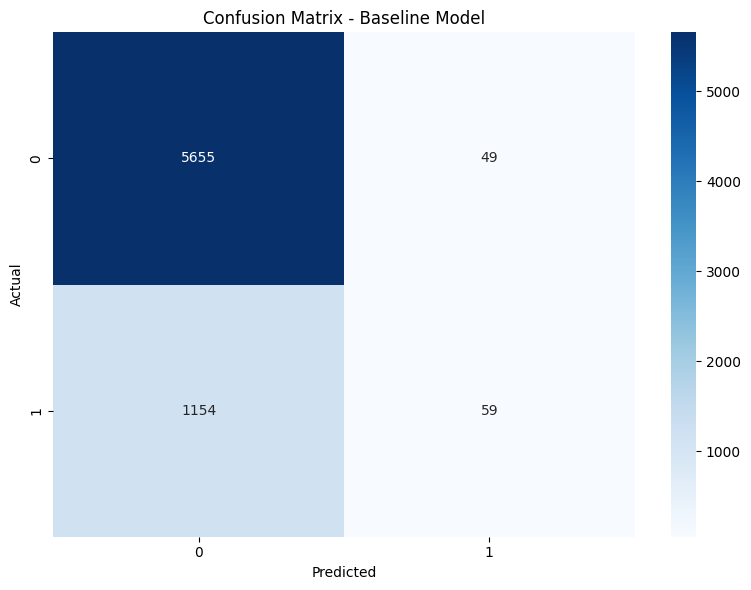

In [90]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

> Results: The model has an overall accuracy of 82,6% that would seem promising. However, the classification report reveals significant imbalance in performance between the two classes. The model does a good job of predicting non-churns, precision 0,83 and recall 0,99, but only 0,55 precision and 0,05 recall for churns. This indicates that while the model rarely misclassifies non-churns, it fails to identify most of the churns. Considering the goal is to reach churners before they leave, this is a big issue and improving the accurate prediction of churns will be the main focus moving forward.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0e20096b-eda0-43a0-b83c-e24d084104d6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>